# Trabalho de Fundamentos em Ciência de Dados
## Tema: Análise do Histórico e Correlação do Bitcoin
### Alunos
- Pedro Henrique de Oliveira Covisi
- Lucca Teodoro Vaz

### Instruções para o Trabalho
1) Descrição do problema e dos dados
- Apresentar o tema escolhido;
- Descrever a origem da base de dados;
- Explicar os objetivos ou perguntas que serão investigadas.
2) Preparação dos dados
- Identificar e tratar valores ausentes ou inconsistentes;
- Remover duplicidades, quando necessário;
- Descrever as etapas de limpeza e pré-processamento dos dados.
3) Análise exploratória dos dados
Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.
Exemplos:
- Distribuição das variáveis;
- Comparação entre grupos;
- Associações entre variáveis;
- Identificação de padrões ou tendências.
Devem ser utilizados pelo menos três tipos diferentes de visualização de dados, como histogramas, gráficos de barras, gráficos de dispersão, boxplots, entre outros.
4) Resultados e conclusões
- Apresentar os principais resultados encontrados;
- Discutir possíveis limitações da base de dados;
- Destacar conclusões e aplicações do estudo

## 1) Descrição do Problema e dos Dados

### 1.1) Tema Escolhido

O tema escolhido foi a análise do histórico e da correlação do Bitcoin com outros ativos financeiros. Assim, nosso objetivo é fazer uma análise profunda da cotação do Bitcoin e da sua correlação, que mudou ao longo dos anos, com outros ativos financeiros relevantes, como o Petróleo, Bolsas Americana e Brasileira, Ouro, Ethereum (segunda maior criptomoeda), Títulos do Tesouro, entre outros. Escolhemos esse tema devido ao grande interesse que temos no mercado financeiro e na influência que o Bitcoin, e outras criptomoedas, vem ganhando com o passar do tempo.

### 1.2) Origem da Base de Dados

Para a realização deste trabalho, são utilizadas duas fontes de dados principais:

1. **Yahoo Finance API (via biblioteca yfinance):**
   Os dados financeiros são coletados dinamicamente utilizando a biblioteca `yfinance` em Python, cobrindo o período a partir de **01/01/2020**. São extraídas as métricas diárias de preço de Abertura (*Open*), Máxima (*High*), Mínima (*Low*) e Fechamento (*Close*) para os seguintes ativos:
   - **Bitcoin (BTC-USD):** Principal criptomoeda e foco central deste estudo.
   - **Ethereum (ETH-USD):** Segunda maior criptomoeda do mercado, para análise de correlação intrassetorial.
   - **S&P 500 (^GSPC):** Índice das 500 maiores empresas dos EUA, representando o mercado de ações americano.
   - **Nasdaq (^IXIC):** Índice de ações composto majoritariamente por empresas de tecnologia.
   - **Ibovespa (^BVSP):** Principal índice de ações do mercado brasileiro.
   - **Ouro (GC=F):** Contratos futuros de ouro, utilizado como commodity de segurança/reserva de valor.
   - **Petróleo (CL=F):** Contratos futuros de petróleo bruto (WTI), representando a principal commodity energética.
   - **Dólar (DX-Y.NYB):** Índice DXY, que mensura o desempenho do dólar americano contra uma cesta de moedas fortes.

2. **Base de Dados Histórica do Bitcoin (bitcoin_dataset.csv):**
   Um conjunto de dados histórico local armazenado em `data/bitcoin_dataset.csv` com dados diários do preço do Bitcoin desde **17/09/2014**. As variáveis incluem as datas e os valores de Abertura (*Open*), Máxima (*High*), Mínima (*Low*), Fechamento (*Close*), Fechamento Ajustado (*Adj Close*) e Volume de negociação.

### 1.3) Objetivos e Perguntas de Pesquisa

1) Fornecer uma breve contextualização sobre o Bitcoin;
2) Fazer observações com relação ao preço do Bitcoin (como volatilidade, drawdown, entre outros);
3) Analisar a correlação do Bitcoin com outros ativos financeiros;
4) Representar essa correlação de forma gráfica e matemática;
5) Realizar análises sobre a cotação do Bitcoin com base em seu histórico e correlação com outros ativos.

## 2) Preparação dos Dados

### 2.1) Importação e Limpeza dos Dados dos Ativos Financeiros

Importando as bibliotecas

In [120]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

Importando os dados financeiros do Yahoo Finance

In [121]:
#Primeiro colocamos os tickers que serão importados em uma lista 
tickers_ativos = [
    "BTC-USD", #Bitcoin
    "ETH-USD", #Ethereum
    "^GSPC", #S&P 500
    "^IXIC", #Nasdaq
    "^BVSP", #Bovespa
    "GC=F", #Ouro 
    "CL=F", #Petróleo
    "DX-Y.NYB", #Dólar
]

#Agora fazemos o donwload dos dados desses ativos tra
df_ativos = yf.download(tickers_ativos, start="2020-01-01")

#Filtrando apenas as 4 métricas desejadas
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_filtrado = df_ativos[metricas_desejadas]

df_ativos = df_filtrado
df_ativos.head(20)

[*********************100%***********************]  8 of 8 completed


Price              Open                                                 \
Ticker          BTC-USD       CL=F   DX-Y.NYB     ETH-USD         GC=F   
Date                                                                     
2020-01-01  7194.892090        NaN        NaN  129.630661          NaN   
2020-01-02  7202.551270  61.599998  96.480003  130.820038  1518.099976   
2020-01-03  6984.428711  61.180000  96.790001  127.411263  1530.099976   
2020-01-04  7345.375488        NaN        NaN  134.168518          NaN   
2020-01-05  7410.451660        NaN        NaN  135.072098          NaN   
2020-01-06  7410.452148  63.709999  96.900002  136.305542  1580.000000   
2020-01-07  7768.682129  62.910000  96.650002  144.311996  1558.300049   
2020-01-08  8161.935547  62.840000  96.830002  143.487823  1579.699951   
2020-01-09  8082.295898  59.990002  97.269997  141.155777  1555.699951   
2020-01-10  7878.307617  59.610001  97.430000  138.967041  1551.199951   
2020-01-11  8162.190918        NaN        NaN  143.409103          NaN   
2020-01-12  8033.261719        NaN        NaN  143.032547          NaN   
2020-01-13  8189.771973  59.040001  97.349998  146.220139  1557.400024   
2020-01-14  8140.933105  58.029999  97.360001  144.251053  1546.699951   
2020-01-15  8825.343750  58.200001  97.379997  165.734619  1548.000000   
2020-01-16  8812.481445  58.099998  97.180000  166.332825  1555.699951   
2020-01-17  8725.209961  58.590000  97.309998  164.489380  1554.099976   
2020-01-18  8927.211914        NaN        NaN  170.747726          NaN   
2020-01-19  8941.445312        NaN        NaN  175.467590          NaN   
2020-01-20  8704.631836        NaN        NaN  166.904129          NaN   

Price                                                  High             ...  \
Ticker         ^BVSP        ^GSPC        ^IXIC      BTC-USD       CL=F  ...   
Date                                                                    ...   
2020-01-01       NaN          NaN          NaN  7254.330566        NaN  ...   
2020-01-02  115652.0  3244.669922  9039.459961  7212.155273  61.599998  ...   
2020-01-03  118564.0  3226.360107  8976.429688  7413.715332  64.089996  ...   
2020-01-04       NaN          NaN          NaN  7427.385742        NaN  ...   
2020-01-05       NaN          NaN          NaN  7544.497070        NaN  ...   
2020-01-06  117707.0  3217.550049  8943.500000  7781.867188  64.720001  ...   
2020-01-07  116872.0  3241.860107  9076.639648  8178.215820  63.150002  ...   
2020-01-08  116667.0  3238.590088  9068.030273  8396.738281  65.650002  ...   
2020-01-09  116248.0  3266.030029  9202.269531  8082.295898  60.310001  ...   
2020-01-10  115948.0  3281.810059  9232.950195  8166.554199  59.779999  ...   
2020-01-11       NaN          NaN          NaN  8218.359375        NaN  ...   
2020-01-12       NaN          NaN          NaN  8200.063477        NaN  ...   
2020-01-13  115503.0  3271.129883  9213.719727  8197.788086  59.270000  ...   
2020-01-14  117325.0  3285.350098  9270.610352  8879.511719  58.720001  ...   
2020-01-15  117632.0  3282.270020  9253.759766  8890.117188  58.360001  ...   
2020-01-16  116415.0  3302.969971  9313.450195  8846.460938  58.869999  ...   
2020-01-17  116710.0  3323.659912  9392.370117  8958.122070  58.980000  ...   
2020-01-18       NaN          NaN          NaN  9012.198242        NaN  ...   
2020-01-19       NaN          NaN          NaN  9164.362305        NaN  ...   
2020-01-20  118478.0          NaN          NaN  8745.590820        NaN  ...   

Price               Low                     Close                        \
Ticker            ^GSPC        ^IXIC      BTC-USD       CL=F   DX-Y.NYB   
Date                                                                      
2020-01-01          NaN          NaN  7200.174316        NaN        NaN   
2020-01-02  3235.530029  9010.889648  6985.470215  61.180000  96.849998   
2020-01-03  3222.340088  8976.429688  7344.884277  63.049999  96.839996   
2020-01-04          NaN      

Mudando o nome das colunas para torná-las mais legíveis

In [122]:
df_ativos = df_ativos.rename(columns={
    '^BVSP': 'Bovespa',
    'BTC-USD': 'Bitcoin',
    'ETH-USD': 'Ethereum',
    '^GSPC': 'SP500',
    '^IXIC': 'Nasdaq',
    'CL=F': 'Petróleo',
    'GC=F': 'Ouro',
    'DX-Y.NYB' : 'Dólar'
})

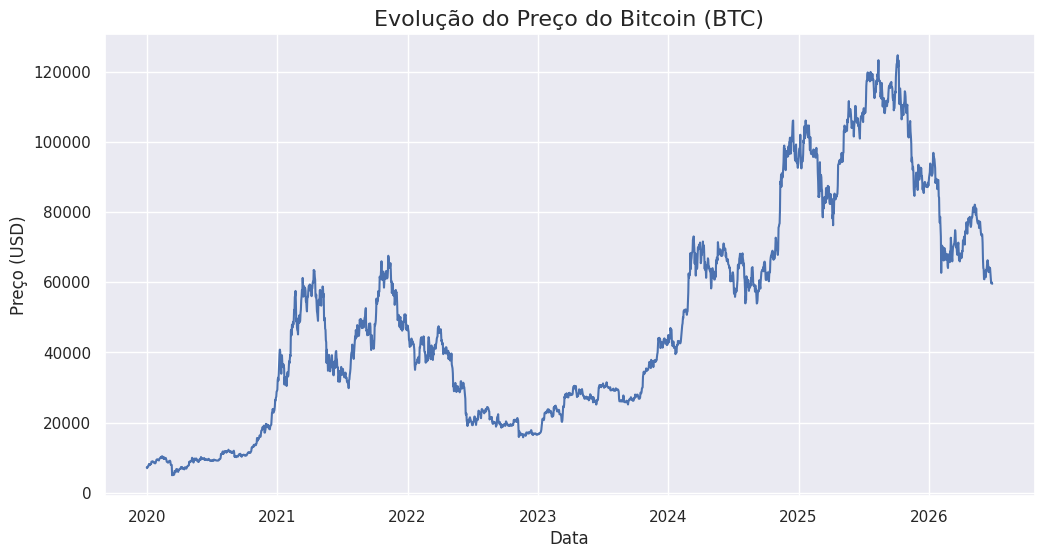

In [123]:
btc_close = df_ativos[('Close','Bitcoin')].reset_index(name = 'Bitcoin')

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))

sns.lineplot(x='Date', y='Bitcoin', data=btc_close)

plt.title('Evolução do Preço do Bitcoin (BTC)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)

plt.show()

### 2.2) Verificação e Tratamento de Dados Faltantes

In [124]:
# Verificação dos dados faltantes
dados = df_ativos
dados.isna().sum() #Conta número de dados faltantes e imprime os resultados

Price  Ticker  
Open   Bitcoin       0
       Petróleo    739
       Dólar       739
       Ethereum      0
       Ouro        739
       Bovespa     757
       SP500       742
       Nasdaq      742
High   Bitcoin       0
       Petróleo    739
       Dólar       739
       Ethereum      0
       Ouro        739
       Bovespa     757
       SP500       742
       Nasdaq      742
Low    Bitcoin       0
       Petróleo    739
       Dólar       739
       Ethereum      0
       Ouro        739
       Bovespa     757
       SP500       742
       Nasdaq      742
Close  Bitcoin       0
       Petróleo    739
       Dólar       739
       Ethereum      0
       Ouro        739
       Bovespa     757
       SP500       742
       Nasdaq      742
dtype: int64

A partir dessa verificação, apresentam-se vários dados faltantes, os quais já eram esperados. Isso ocorre porque, diferentemente dos mercados tradicionais, o Bitcoin e o Ethereum são negociados nos fins de semana e feriados.

Assim, para analisar a correlação entre o Bitcoin e outros ativos (exceto o Ethereum), existem duas opções:
1) Adicionar, artificialmente, os dados de fechamento do dia anterior para os dias com dados faltantes nos ativos financeiros tradicionais;
2) Ou excluir os dados do Bitcoin e do Ethereum nos fins de semana e feriados.

Para deixar a análise de correlação a mais assertiva possível, optamos pela segunda opção. Mas antes vamos copiar as colunas relativas ao Ethereum e ao Bitcoin para poder realizar análises mais assertivas entre as criptomoedas sem perder os dados dos fins de semana.

In [125]:
df_ativos

Price               Open                                                   \
Ticker           Bitcoin   Petróleo       Dólar     Ethereum         Ouro   
Date                                                                        
2020-01-01   7194.892090        NaN         NaN   129.630661          NaN   
2020-01-02   7202.551270  61.599998   96.480003   130.820038  1518.099976   
2020-01-03   6984.428711  61.180000   96.790001   127.411263  1530.099976   
2020-01-04   7345.375488        NaN         NaN   134.168518          NaN   
2020-01-05   7410.451660        NaN         NaN   135.072098          NaN   
...                  ...        ...         ...          ...          ...   
2026-06-24  62663.031250  73.129997  101.370003  1665.309814  4104.399902   
2026-06-25  60992.070312  69.949997  101.599998  1619.885376  3988.399902   
2026-06-26  59712.054688  71.440002  101.500000  1564.613647  4078.699951   
2026-06-27  60016.312500        NaN         NaN  1576.591187          NaN   
2026-06-28  59939.523438  70.500000  101.367996  1571.681763  4101.100098   

Price                                                    High             ...  \
Ticker       Bovespa        SP500        Nasdaq       Bitcoin   Petróleo  ...   
Date                                                                      ...   
2020-01-01       NaN          NaN           NaN   7254.330566        NaN  ...   
2020-01-02  115652.0  3244.669922   9039.459961   7212.155273  61.599998  ...   
2020-01-03  118564.0  3226.360107   8976.429688   7413.715332  64.089996  ...   
2020-01-04       NaN          NaN           NaN   7427.385742        NaN  ...   
2020-01-05       NaN          NaN           NaN   7544.497070        NaN  ...   
...              ...          ...           ...           ...        ...  ...   
2026-06-24  171256.0  7370.879883  25578.619141  63097.757812  73.180000  ...   
2026-06-25  170508.0  7404.910156  25724.779297  61868.906250  72.500000  ...   
2026-06-26  171990.0  7312.740234  25105.410156  60647.187500  71.860001  ...   
2026-06-27       NaN          NaN           NaN  60835.046875        NaN  ...   
2026-06-28       NaN          NaN           NaN  60379.679688  70.970001  ...   

Price               Low                       Close                         \
Ticker            SP500        Nasdaq       Bitcoin   Petróleo       Dólar   
Date                                                                         
2020-01-01          NaN           NaN   7200.174316        NaN         NaN   
2020-01-02  3235.530029   9010.889648   6985.470215  61.180000   96.849998   
2020-01-03  3222.340088   8976.429688   7344.884277  63.049999   96.839996   
2020-01-04          NaN           NaN   7410.656738        NaN         NaN   
2020-01-05          NaN           NaN   7411.317383        NaN         NaN   
...                 ...           ...           ...        ...         ...   
2026-06-24  7336.819824  25354.660156  60995.132812  70.339996  101.610001   
2026-06-25  7323.500000  25123.429688  59721.675781  71.919998  101.430000   
2026-06-26  7294.180176  25014.960938  60016.429688  69.230003  101.360001   
2026-06-27          NaN           NaN  59940.097656        NaN         NaN   
2026-06-28          NaN           NaN  59578.199219  69.809998  101.383003   

Price                                                                      
Ticker         Ethereum         Ouro   Bovespa        SP500        Nasdaq  
Date                                                                       
2020-01-01   130.802002          NaN       NaN          NaN           NaN  
2020-01-02   127.410179  1524.500000  118573.0  3257.850098   9092.190430  
2020-01-03   134.171707  1549.199951  117707.0  3234.850098   9020.769531  
2020-01-04   135.069366          NaN       NaN          NaN           NaN  
2020-01-05   136.276779          NaN       NaN          NaN           NaN  
...                 ...          ...       ...          ...           ...  
2026-06-2

In [126]:
df_btc = df_ativos.xs('Bitcoin', level=1, axis=1).copy()
df_btc

Price,Open,High,Low,Close
Date,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383
...,...,...,...,...
2026-06-24,62663.031250,63097.757812,59029.855469,60995.132812
2026-06-25,60992.070312,61868.906250,58075.921875,59721.675781
2026-06-26,59712.054688,60647.187500,58269.125000,60016.429688


In [127]:
df_eth = df_ativos.xs('Ethereum', level=1, axis=1).copy()
df_eth

Price,Open,High,Low,Close
Date,,,,
2020-01-01,129.630661,132.835358,129.198288,130.802002
2020-01-02,130.820038,130.820038,126.954910,127.410179
2020-01-03,127.411263,134.554016,126.490021,134.171707
2020-01-04,134.168518,136.052719,133.040558,135.069366
2020-01-05,135.072098,139.410202,135.045624,136.276779
...,...,...,...,...
2026-06-24,1665.309814,1687.492310,1551.484253,1619.924927
2026-06-25,1619.885376,1656.646484,1531.780396,1564.816650
2026-06-26,1564.613647,1590.200073,1510.505859,1576.616089


Em relação ao maior número de dados faltantes das bolsas em comparação com as commodities, como a quantidade é reduzida, resolvemos relevar e excluir as observações correspondentes.

Agora, realizamos a exclusão dos dados faltantes.

In [128]:
dados.dropna(inplace=True) 
dados.isna().sum() 

Price  Ticker  
Open   Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
High   Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Low    Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Close  Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
dtype: int64

### 2.3) Cálculo dos Retornos Logarítmicos dos Ativos

Para garantir que as análises de correlação e os futuros modelos de previsão sejam estatisticamente consistentes, calculamos os retornos logarítmicos ($r_t = \ln(P_t / P_{t-1})$) a partir dos preços de fechamento diários (*Close*) de cada ativo.

**Principais motivos para usar os retornos logarítmicos:**
- **Simetria entre ganhos e perdas:** Por exemplo, se um ativo cai 50% e depois sobe 100% para retornar ao preço original, a soma simples dos retornos percentuais é +50% (o que é contraintuitivo), enquanto os retornos logarítmicos correspondentes têm a mesma magnitude mas sinais opostos, anulando-se mutuamente (soma igual a zero);
- **Aditividade no tempo:** O retorno logarítmico acumulado em vários períodos é a soma simples dos retornos de cada período individual;
- **Propriedades estatísticas:** Os retornos logarítmicos aproximam-se mais de uma distribuição normal.

In [129]:
# 1. Filtrando apenas os preços de fechamento ('Close') de cada ativo
df_fechamento = df_ativos['Close']

# Substituindo valores menores ou iguais a zero por NaN (ex: preço negativo do petróleo em abril/2020) para evitar avisos matemáticos no logaritmo
df_fechamento = df_fechamento.mask(df_fechamento <= 0)

# 2. Calculando o retorno logarítmico de todos os ativos
df_retornos_log = np.log(df_fechamento / df_fechamento.shift(1))

# 3. Removendo o primeiro registro e quaisquer NaNs resultantes
df_retornos_log.dropna(inplace=True)

# 4. Exibindo as primeiras linhas
df_retornos_log.head()

Ticker,Bitcoin,Petróleo,Dólar,Ethereum,Ouro,Bovespa,SP500,Nasdaq
Date,,,,,,,,
2020-01-03,0.050172,0.030108,-0.000103,0.051709,0.016072,-0.007330,-0.007085,-0.007886
2020-01-06,0.056166,0.003483,-0.001757,0.072803,0.010914,-0.007068,0.003527,0.005605
2020-01-07,0.049527,-0.009050,0.003202,-0.005282,0.003569,-0.001850,-0.002807,-0.000319
2020-01-08,-0.010322,-0.050538,0.003294,-0.016053,-0.009204,-0.003564,0.004890,0.006667
2020-01-09,-0.025165,-0.000839,0.001540,-0.016265,-0.003667,-0.002584,0.006633,0.008094


## 3) Análise Exploratória dos Dados

### 3.1) Sazonalidade do Bitcoin

#### Como os dias da semana afetam os movimentos nos preços do Bitcoin?

In [130]:
df_btc_close = df_btc['Close'].reset_index(name='Cotação')
df_btc_close

,Date,Cotação
0,2020-01-01,7200.174316
1,2020-01-02,6985.470215
2,2020-01-03,7344.884277
3,2020-01-04,7410.656738
4,2020-01-05,7411.317383
...,...,...
2366,2026-06-24,60995.132812
2367,2026-06-25,59721.675781
2368,2026-06-26,60016.429688
2369,2026-06-27,59940.097656


/tmp/ipykernel_4631/2774534653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')


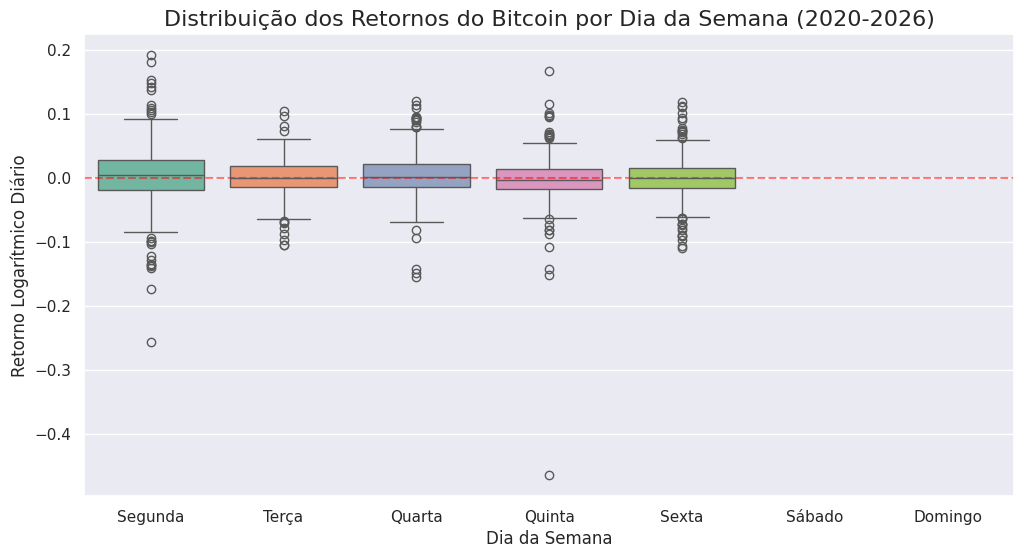

In [ ]:
df_btc_sazonalidade = df_retornos_log[['Bitcoin']].copy()

df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade.index.day_name()

dias_pt = {
    'Monday': 'Segunda', 
    'Tuesday': 'Terça', 
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 
    'Friday': 'Sexta', 
    'Saturday': 'Sábado', 
    'Sunday': 'Domingo'
}
df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade['Dia_da_Semana'].map(dias_pt)

ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(12, 6))AED.git
   11d9418..11ed2e7  main -> main
sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')

plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.title('Distribuição dos Retornos do Bitcoin por Dia da Semana (2020-2026)', fontsize=16)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Retorno Logarítmico Diário', fontsize=12)

plt.show()

#### Conclusão da Análise de Sazonalidade

### 3.2) Correlação com Outros Ativos Financeiros
#### Como os ativos estão correlacionados com o Bitcoin?

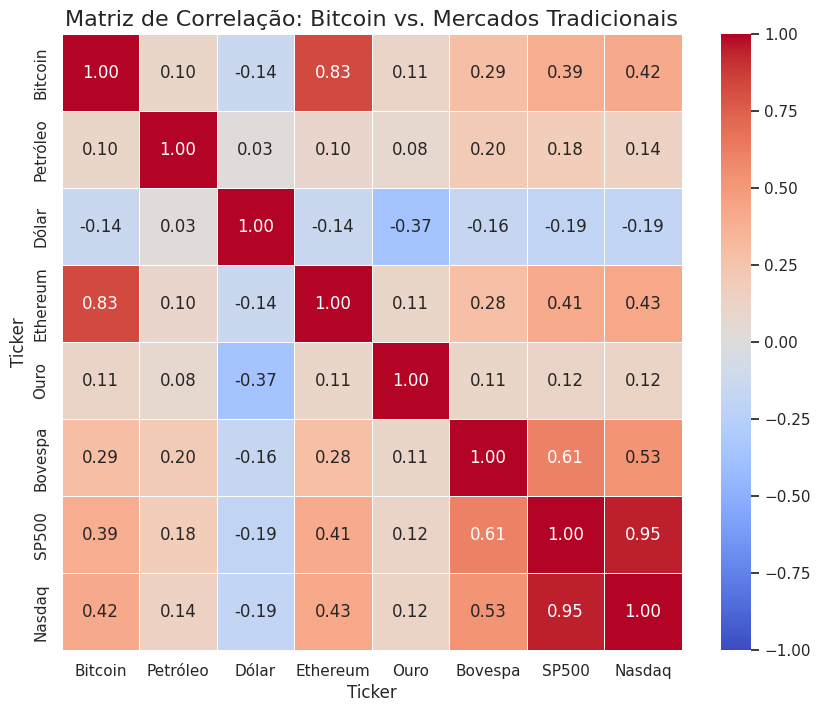

In [132]:
df_final = df_retornos_log.dropna() 

matriz_corr = df_final.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, 
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=0.5)

plt.title('Matriz de Correlação: Bitcoin vs. Mercados Tradicionais', fontsize=16)
plt.show()

#### Conclusão sobre a Correlação


### 3.3) Análise de Volatilidade
#### O Bitcoin realmente é mais volátil?

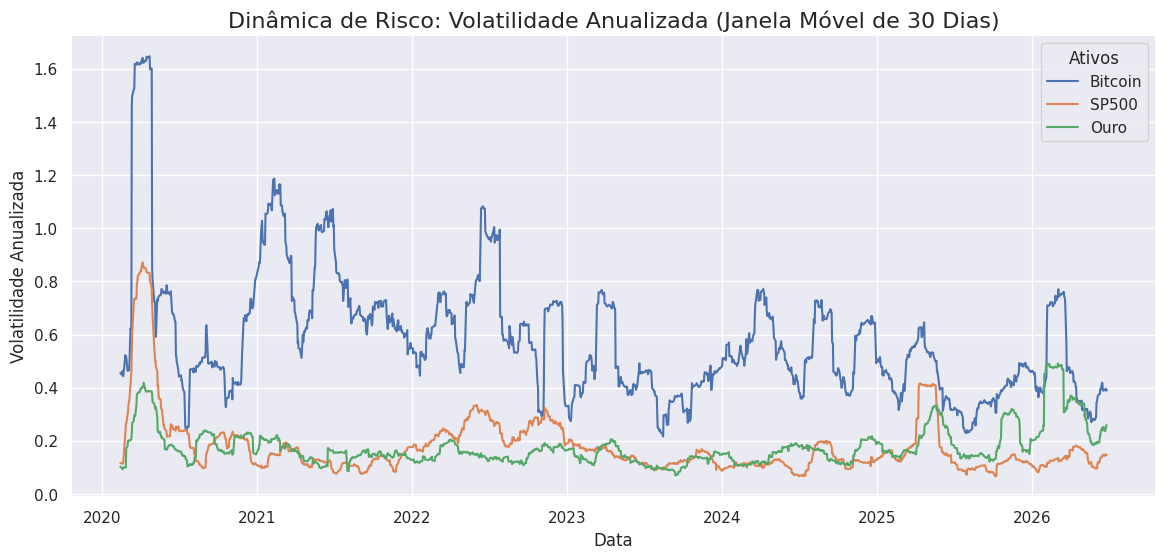

In [133]:
janela = 30

vol_movel = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

plt.figure(figsize=(14, 6))
sns.lineplot(data=vol_movel, dashes=False, linewidth=1.5)

plt.title('Dinâmica de Risco: Volatilidade Anualizada (Janela Móvel de 30 Dias)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volatilidade Anualizada', fontsize=12)
plt.legend(title='Ativos')

plt.show()

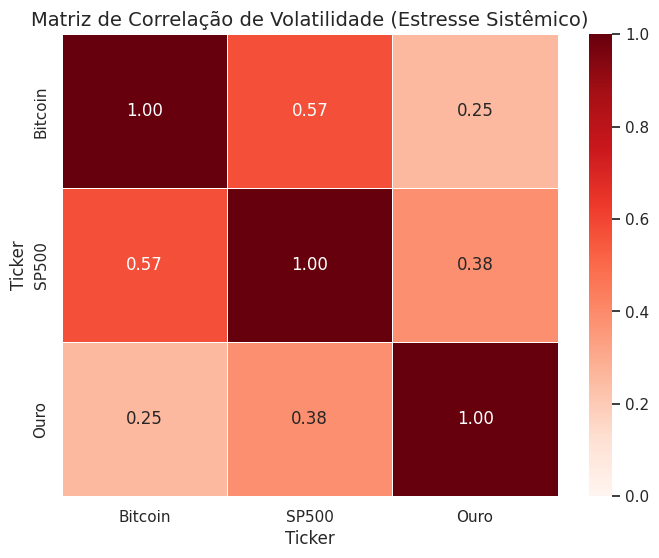

In [134]:
janela = 30
df_volatilidade = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

df_volatilidade = df_volatilidade.dropna()

corr_volatilidade = df_volatilidade.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_volatilidade, annot=True, cmap='Reds', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação de Volatilidade (Estresse Sistêmico)', fontsize=14)
plt.show()

#### 3.4 Risco e Retorno
O Bitcoin é mais arriscado que outros ativos? O retorno compensa o risco?1

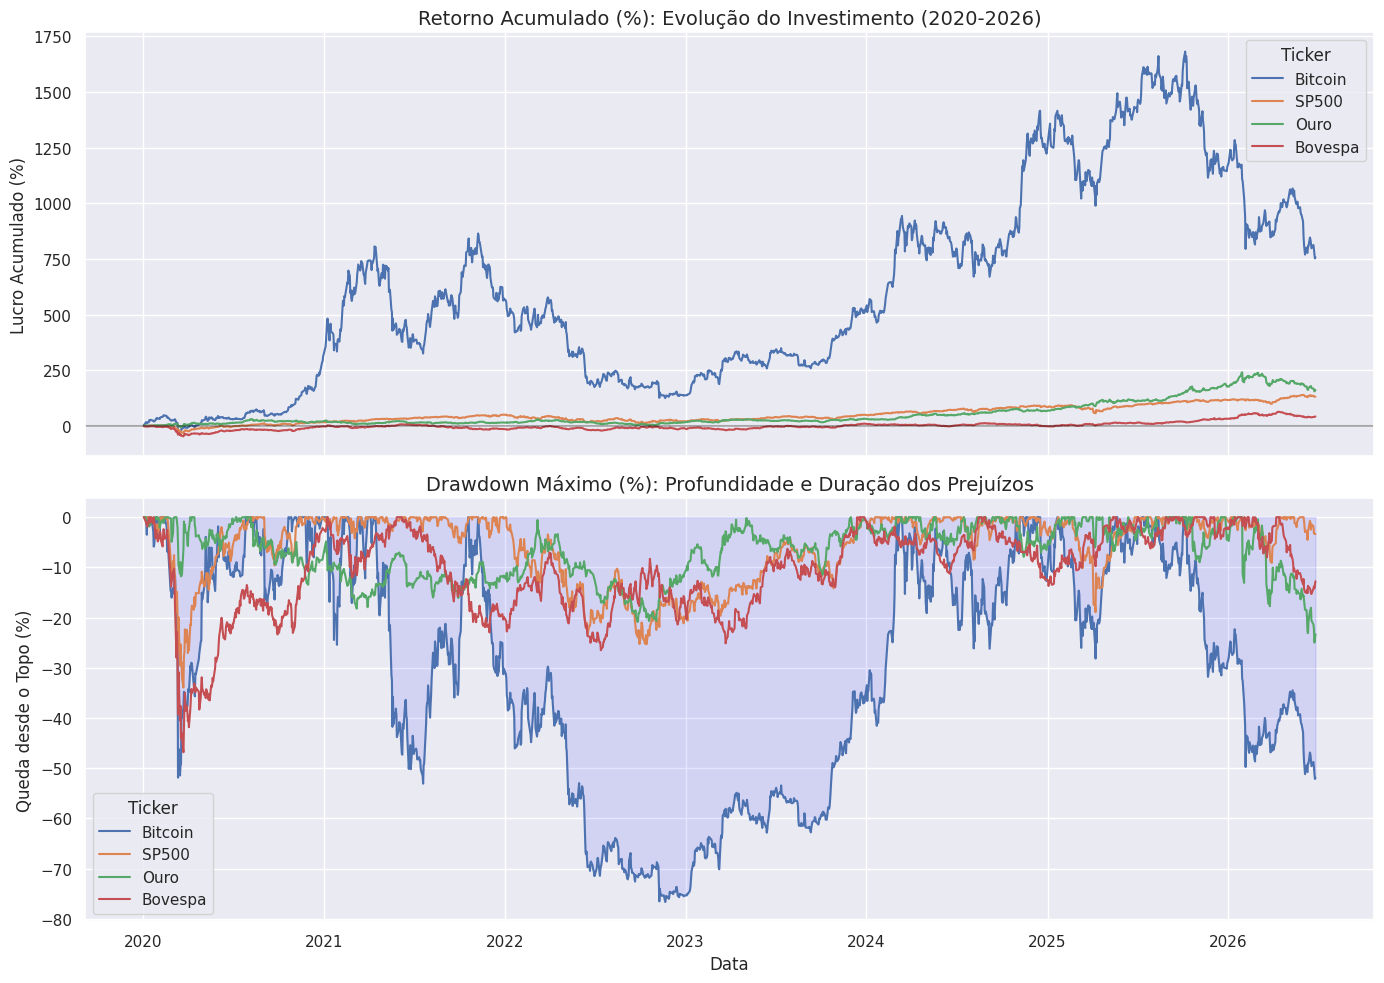

In [135]:
df_acumulado = np.exp(df_retornos_log[['Bitcoin', 'SP500', 'Ouro', 'Bovespa']].cumsum())

df_retorno_pct = (df_acumulado - 1) * 100

picos_historicos = df_acumulado.cummax()
df_drawdown = ((df_acumulado - picos_historicos) / picos_historicos) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(data=df_retorno_pct, ax=axes[0], dashes=False, linewidth=1.5)
axes[0].set_title('Retorno Acumulado (%): Evolução do Investimento (2020-2026)', fontsize=14)
axes[0].set_ylabel('Lucro Acumulado (%)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='-', alpha=0.3)

sns.lineplot(data=df_drawdown, ax=axes[1], dashes=False, linewidth=1.5)
axes[1].set_title('Drawdown Máximo (%): Profundidade e Duração dos Prejuízos', fontsize=14)
axes[1].set_ylabel('Queda desde o Topo (%)', fontsize=12)
axes[1].set_xlabel('Data', fontsize=12)
axes[1].fill_between(df_drawdown.index, df_drawdown['Bitcoin'], 0, color='blue', alpha=0.1)

plt.tight_layout()
plt.show()

#### 4. Disclaimer Final ⚠️
Essa é uma análise exploratória envolvendo dados dos mercados analisados e possui limitações inerentes, pois se baseia exclusivamente na observação de padrões visuais e medidas descritivas. O fato de encontrarmos associações não garante que essas diferenças possuam significância estatística, pois podem ser mero fruto do acaso.